# 問題
ベクトル空間上の国名に関する単語ベクトルをt-SNEで可視化せよ。

In [2]:
def get_word():
    categories1 = ['capital-common-countries', 'capital-world']
    categories2 = ['currency', 'gram6-nationality-adjective']
    countries = set()
    current_category = None
    txt_path = "単語ベクトルの質問.txt"

    with open(txt_path, 'r', encoding='utf-8') as f:
        for row in f:
            row = row.strip()
            if not row:
                continue
            # カテゴリ宣言行
            if row.startswith(':'):
                current_category = row[1:].strip()  
                continue

            # データ行
            parts = row.split()
            if current_category in categories1:
                countries.add(parts[1])  # 2列目の国
                countries.add(parts[3])  # 4列目の国
            elif current_category in categories2:
                countries.add(parts[0])  # 1列目の国

    return list(countries)

from gensim.models import KeyedVectors
def word2vector(countries_list):
  kv_path = "./GoogleNews-vectors-negative300.bin"
  kv = KeyedVectors.load_word2vec_format(kv_path, binary=True)
  country_vec = []
  for country in countries_list:
    if country in kv:
      vec = kv[country] 
      country_vec.append(vec)
    else:
      print("キーが見つかりませんでした:", country)
  return country_vec

countries = get_word()
countries_vec = word2vector(get_word())

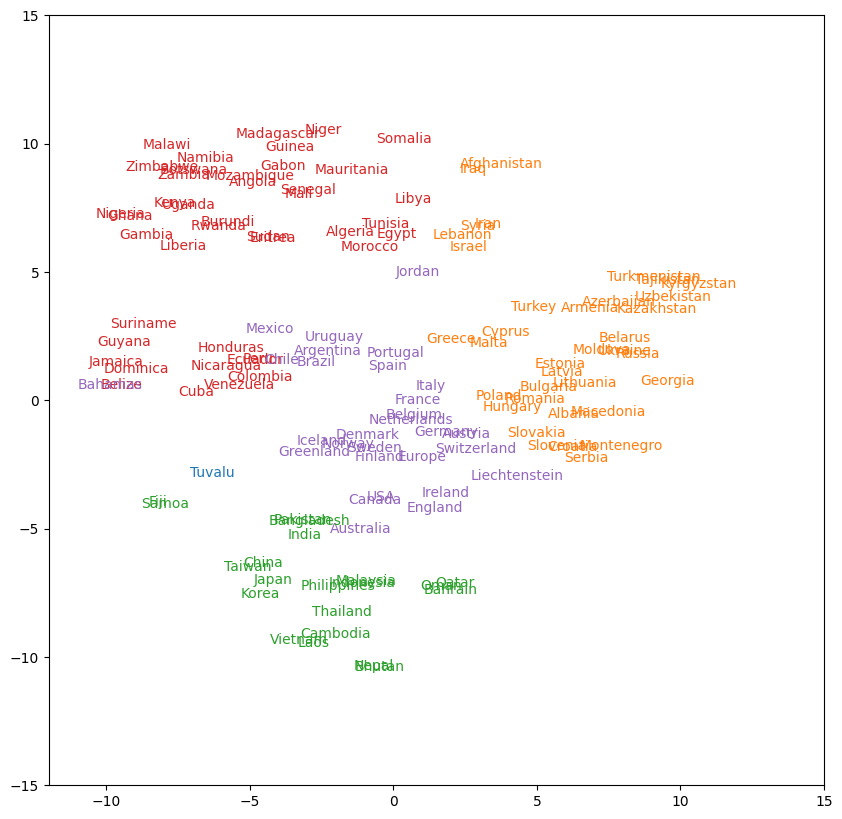

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

tsne = TSNE(n_components=2, random_state=64)
X_reduced = tsne.fit_transform(np.array(countries_vec))
kmeans = KMeans(n_clusters=5)
kmeans.fit(countries_vec)

plt.figure(figsize=(10, 10))
for x, country, color in zip(X_reduced, countries, kmeans.labels_):
    plt.text(x[0], x[1], country, color='C{}'.format(color))
plt.xlim([-12, 15])
plt.ylim([-15, 15])
plt.show()